# 成交额 20 日波动率因子回测

## tl;dr

本次已执行样本覆盖 2020-01-02 至 2026-07-31，共 1,594 个交易日、7,553,382 条有效股票日记录。市值中性化后的成交额 20 日波动率因子，其未来 1/3/5 日 RankIC 分别为 -0.0551、-0.0723、-0.0819；G5-G1 年化多空收益分别为 -30.15%、-28.16%、-26.74%。高成交额波动组显著落后低波动组，结果支持将该指标作为负向因子使用，但当前结论仍基于同收盘成交、动态股票池和无交易成本的理论框架，不能直接视为可交易策略收益。

## Context & Methods

目标是检验 A 股过去 20 个交易日成交额波动率对未来 1、3、5 个交易日收益的截面解释能力。

因子定义为：

$$AmountVol_{20,t}=STD(amount_{t-19},\ldots,amount_t)$$

其中 `amount` 为项目日线数据中的当日成交额。实现使用 Polars `rolling_std(window_size=20, min_samples=20, ddof=1)`，即样本标准差；窗口包含当日成交额，只使用当日及历史数据。`analyze_factor` 从下一交易日收益开始评价，避免把同一日收益同时作为因子信息和未来收益。

### Key Assumptions

- 分析区间为 2020-01-01 至 2026-08-01，并额外向前读取 60 个自然日作为滚动窗口预热期。
- 严格使用原始成交额标准差，不改成对数成交额波动率或成交额变异系数；停牌等场景记录的零成交额也按源数据原值进入窗口。
- 与参考框架一致，每日以 `total_mv` 做线性总市值中性化；G1 为中性化因子最低组，G5 为最高组。
- benchmark 是当日有效股票池的等权收益，不是沪深 300 等可交易指数。
- 结果属于理论因子研究，不含手续费、滑点、涨跌停成交约束和真实资金容量。

In [1]:
# 统一参数和依赖；使用项目约定的 quant 内核执行。
import datetime as dt
import sys
from pathlib import Path

import numpy as np
import polars as pl
from IPython.display import display

project_root = Path(r"C:\Users\20561\Desktop\策略")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from my_utils.fun import read_day_data
from 因子回测.alpha import analyze_factor, ols_neutralize

analysis_start_date = dt.date(2020, 1, 1)
analysis_end_date = dt.date(2026, 8, 1)
warmup_calendar_days = 60
load_start_date = analysis_start_date - dt.timedelta(days=warmup_calendar_days)
amount_window = 20
ret_windows = [1, 3, 5]
ic_windows = [1, 3, 5]
group_num = 5

## Data

从项目本地 `rq_stock_all_data` Parquet 数据集读取日线。预热期只参与滚动因子计算，不进入最终回测统计。数据质量摘要会检查主键重复、核心字段缺失、零成交额和负成交额记录，避免在不了解源数据口径时静默推进。

In [2]:
def profile_stock_daily_source(data: pl.DataFrame) -> pl.DataFrame:
    """汇总日线源数据的主键、日期、成交额和核心字段完整性。"""
    core_fields = [
        "open",
        "close",
        "pre_close",
        "limit_up",
        "limit_down",
        "amount",
        "total_mv",
    ]
    required = {"trading_date", "code", *core_fields}
    missing = sorted(required.difference(data.columns))
    if missing:
        raise ValueError("缺少必要列: " + ", ".join(missing))

    return data.select(
        pl.len().alias("rows"),
        pl.col("trading_date").min().alias("date_min"),
        pl.col("trading_date").max().alias("date_max"),
        pl.col("code").n_unique().alias("stocks"),
        pl.struct(["trading_date", "code"])
        .is_duplicated()
        .sum()
        .alias("duplicate_key_rows"),
        *[
            pl.col(column).null_count().alias(f"{column}_nulls")
            for column in core_fields
        ],
        (pl.col("amount") == 0).sum().alias("zero_amount_rows"),
        (pl.col("amount") < 0).sum().alias("negative_amount_rows"),
    )


required_fields = [
    "code",
    "name",
    "trading_date",
    "open",
    "close",
    "pre_close",
    "pct",
    "limit_up",
    "limit_down",
    "amount",
    "is_st",
    "is_suspended",
    "total_mv",
]
raw_stock_data = read_day_data(
    start_date=load_start_date,
    end_date=analysis_end_date,
    fields=required_fields,
)
source_quality_summary = profile_stock_daily_source(raw_stock_data)

# 核心行情或中性化字段缺失的记录无法参与因子排序和收益评价。
stock_data = raw_stock_data.drop_nulls(
    subset=[
        "open",
        "close",
        "pre_close",
        "limit_up",
        "limit_down",
        "amount",
        "total_mv",
    ]
)
del raw_stock_data

print(
    f"读取 {stock_data.height:,} 行，"
    f"日期范围 {stock_data['trading_date'].min()} 至 "
    f"{stock_data['trading_date'].max()}"
)
display(source_quality_summary)
stock_data.head()

读取 7,742,499 行，日期范围 2019-11-04 至 2026-07-31


rows,date_min,date_max,stocks,duplicate_key_rows,open_nulls,close_nulls,pre_close_nulls,limit_up_nulls,limit_down_nulls,amount_nulls,total_mv_nulls,zero_amount_rows,negative_amount_rows
u32,date,date,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
7742499,2019-11-04,2026-07-31,5736,0,0,0,0,0,0,0,0,23960,0


code,name,trading_date,open,close,pre_close,pct,limit_up,limit_down,amount,is_st,is_suspended,total_mv
str,str,date,f64,f64,f64,f64,f64,f64,f64,bool,bool,f64
"""SHSE.600000""","""浦发银行""",2019-11-04,12.75,12.74,12.75,-0.078431,14.03,11.48,6.34816416e8,false,false,3.7395e11
"""SHSE.600004""","""白云机场""",2019-11-04,18.01,18.58,18.11,2.595251,19.92,16.3,7.32041333e8,false,false,3.8448e10
"""SHSE.600006""","""东风股份""",2019-11-04,4.44,4.44,4.44,0.0,4.88,4.0,2.8919291e7,false,false,8.8800e9
"""SHSE.600007""","""中国国贸""",2019-11-04,17.67,17.66,17.67,-0.056593,19.44,15.9,1.4661056e7,false,false,1.7789e10
"""SHSE.600008""","""首创环保""",2019-11-04,3.34,3.35,3.34,0.299401,3.67,3.01,3.5481283e7,false,false,1.9046e10


## Factor Construction

先按股票和交易日排序，再对每只股票独立计算成交额的 20 日滚动样本标准差。`min_samples=20` 明确要求完整窗口，前 19 条有效记录保持为空；因子在 $t$ 日只包含截至 $t$ 日收盘后已经观测到的成交额。

In [3]:
def add_amount_volatility_20d_factor(
    data: pl.DataFrame, window: int = 20
) -> pl.DataFrame:
    """按股票追加过去 window 个交易日原始成交额的样本标准差。

    窗口包含当前交易日，只使用当前及历史记录；完整窗口形成前返回 null。
    `ddof=1` 对应样本标准差。零成交额保留，避免擅自改变源数据口径。
    """
    required = {"code", "trading_date", "amount"}
    missing = sorted(required.difference(data.columns))
    if missing:
        raise ValueError("缺少必要列: " + ", ".join(missing))
    if window < 2:
        raise ValueError("window 必须是不小于 2 的整数")

    factor_col = f"amount_volatility_{window}d"
    return data.sort(["code", "trading_date"]).with_columns(
        pl.col("amount")
        .rolling_std(
            window_size=window,
            min_samples=window,
            ddof=1,
        )
        .over("code")
        .alias(factor_col)
    )


stock_data = (
    add_amount_volatility_20d_factor(stock_data, window=amount_window)
    .with_columns(
        (pl.col("close") / pl.col("pre_close") - 1).alias("daily_ret")
    )
)
factor_col = f"amount_volatility_{amount_window}d"

# 预热完成后再截取正式分析区间，并排除无法用于排序或收益评价的非有限值。
evaluation_stock_data = (
    stock_data.filter(
        pl.col("trading_date").is_between(
            analysis_start_date, analysis_end_date
        )
    )
    .drop_nulls([factor_col, "daily_ret", "total_mv"])
    .filter(
        pl.col(factor_col).is_finite()
        & pl.col("daily_ret").is_finite()
        & pl.col("total_mv").is_finite()
    )
)

# 复用参考框架：每日截面用线性总市值中性化，回归残差作为最终排序因子。
evaluation_stock_data = (
    evaluation_stock_data.group_by("trading_date", maintain_order=True)
    .map_groups(
        lambda frame: ols_neutralize(
            frame,
            y_column=factor_col,
            x_columns=["total_mv"],
        )
    )
    .sort(["trading_date", "code"])
)
neutralized_factor_col = f"{factor_col}_neutralized"

analysis_data = (
    evaluation_stock_data.drop_nulls([neutralized_factor_col])
    .filter(pl.col(neutralized_factor_col).is_finite())
    .with_columns(
        pl.col("daily_ret").mean().over("trading_date").alias("benchmark_ret")
    )
    .select(
        "trading_date",
        "code",
        "name",
        factor_col,
        neutralized_factor_col,
        "daily_ret",
        "benchmark_ret",
        "amount",
        "total_mv",
        "is_st",
        "is_suspended",
    )
)

analysis_data.head()

trading_date,code,name,amount_volatility_20d,amount_volatility_20d_neutralized,daily_ret,benchmark_ret,amount,total_mv,is_st,is_suspended
date,str,str,f64,f64,f64,f64,f64,f64,bool,bool
2020-01-02,"""SHSE.600000""","""浦发银行""",1.6782e8,-2.8837e8,0.008084,0.018269,6.47446166e8,3.6602e11,false,false
2020-01-02,"""SHSE.600004""","""白云机场""",1.0298e8,1.0140e7,0.004011,0.018269,3.11394028e8,3.6254e10,false,false
2020-01-02,"""SHSE.600006""","""东风股份""",2.3348e7,-3.9798e7,0.015284,0.018269,6.1341914e7,9.3000e9,false,false
2020-01-02,"""SHSE.600007""","""中国国贸""",8.4727e6,-6.3904e7,0.002857,0.018269,2.8474105e7,1.7678e10,false,false
2020-01-02,"""SHSE.600008""","""首创环保""",2.3762e7,-4.9997e7,0.012158,0.018269,7.1460782e7,1.8933e10,false,false


## Validation Checks

以下检查覆盖滚动窗口完整性、收益单位、样本规模、因子分布和市值中性化残差。核心函数另有确定性小样本测试，用于捕获跨股票串窗、少算一期和未来成交额泄漏。

In [4]:
# 1. 完整窗口前不得提前产生因子；amount 已在计算前去除空值。
window_integrity_check = (
    stock_data.sort(["code", "trading_date"])
    .with_columns(
        pl.col("amount").cum_count().over("code").alias("observation_number")
    )
    .select(
        (
            (pl.col("observation_number") < amount_window)
            & pl.col(factor_col).is_not_null()
        )
        .sum()
        .alias("premature_non_nulls"),
        (
            (pl.col("observation_number") >= amount_window)
            & pl.col(factor_col).is_null()
        )
        .sum()
        .alias("unexpected_nulls_after_full_window"),
    )
)

# 2. 本地 pct 以百分数存储；daily_ret 应与 pct/100 对齐。
return_scale_check = stock_data.select(
    (pl.col("daily_ret") - pl.col("pct") / 100)
    .abs()
    .max()
    .alias("daily_ret_vs_pct_div_100_max_abs_diff")
)

# 3. 汇总最终有效样本和原始因子分布，显式暴露零成交额与停牌记录占比。
sample_summary = analysis_data.select(
    pl.len().alias("rows"),
    pl.col("trading_date").n_unique().alias("trading_days"),
    pl.col("code").n_unique().alias("stocks"),
    pl.col(factor_col).min().alias("factor_min"),
    pl.col(factor_col).quantile(0.01).alias("factor_p01"),
    pl.col(factor_col).median().alias("factor_median"),
    pl.col(factor_col).quantile(0.99).alias("factor_p99"),
    pl.col(factor_col).max().alias("factor_max"),
    (pl.col("amount") == 0).mean().alias("zero_amount_row_ratio"),
    pl.col("is_st").mean().alias("st_row_ratio"),
    pl.col("is_suspended").mean().alias("suspended_row_ratio"),
)
daily_sample_count = (
    analysis_data.group_by("trading_date").len().select(
        pl.col("len").min().alias("daily_stock_count_min"),
        pl.col("len").median().alias("daily_stock_count_median"),
        pl.col("len").max().alias("daily_stock_count_max"),
    )
)

# 4. 对比中性化前后因子与 total_mv 的每日截面线性相关性。
neutralization_check = (
    analysis_data.group_by("trading_date")
    .agg(
        pl.col(neutralized_factor_col).mean().alias("residual_mean"),
        pl.corr(factor_col, "total_mv").alias("raw_mv_corr"),
        pl.corr(neutralized_factor_col, "total_mv").alias(
            "residual_mv_corr"
        ),
    )
    .select(
        pl.col("residual_mean").abs().max().alias(
            "max_abs_daily_residual_mean"
        ),
        pl.col("raw_mv_corr").abs().mean().alias("mean_abs_daily_raw_mv_corr"),
        pl.col("residual_mv_corr").abs().max().alias(
            "max_abs_daily_residual_mv_corr"
        ),
    )
)

display(window_integrity_check)
display(return_scale_check)
display(sample_summary)
display(daily_sample_count)
display(neutralization_check)

premature_non_nulls,unexpected_nulls_after_full_window
u32,u32
0,0


daily_ret_vs_pct_div_100_max_abs_diff
f64
8.8818e-16


rows,trading_days,stocks,factor_min,factor_p01,factor_median,factor_p99,factor_max,zero_amount_row_ratio,st_row_ratio,suspended_row_ratio
u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64
7553382,1594,5423,0.0,2.8360e6,4.6000e7,1.1267e9,2.2996e10,0.003053,0.035037,0.003053


daily_stock_count_min,daily_stock_count_median,daily_stock_count_max
u32,f64,u32
3741,4938.5,5205


max_abs_daily_residual_mean,mean_abs_daily_raw_mv_corr,max_abs_daily_residual_mv_corr
f64,f64,f64
2.5381e-7,0.435676,1.7755e-15


## Results

`ret_windows` 表示分组调仓间隔，调仓日分组用于之后 1/3/5 个交易日的逐日收益；`ic_windows` 表示因子与未来累计 1/3/5 日收益的相关窗口。

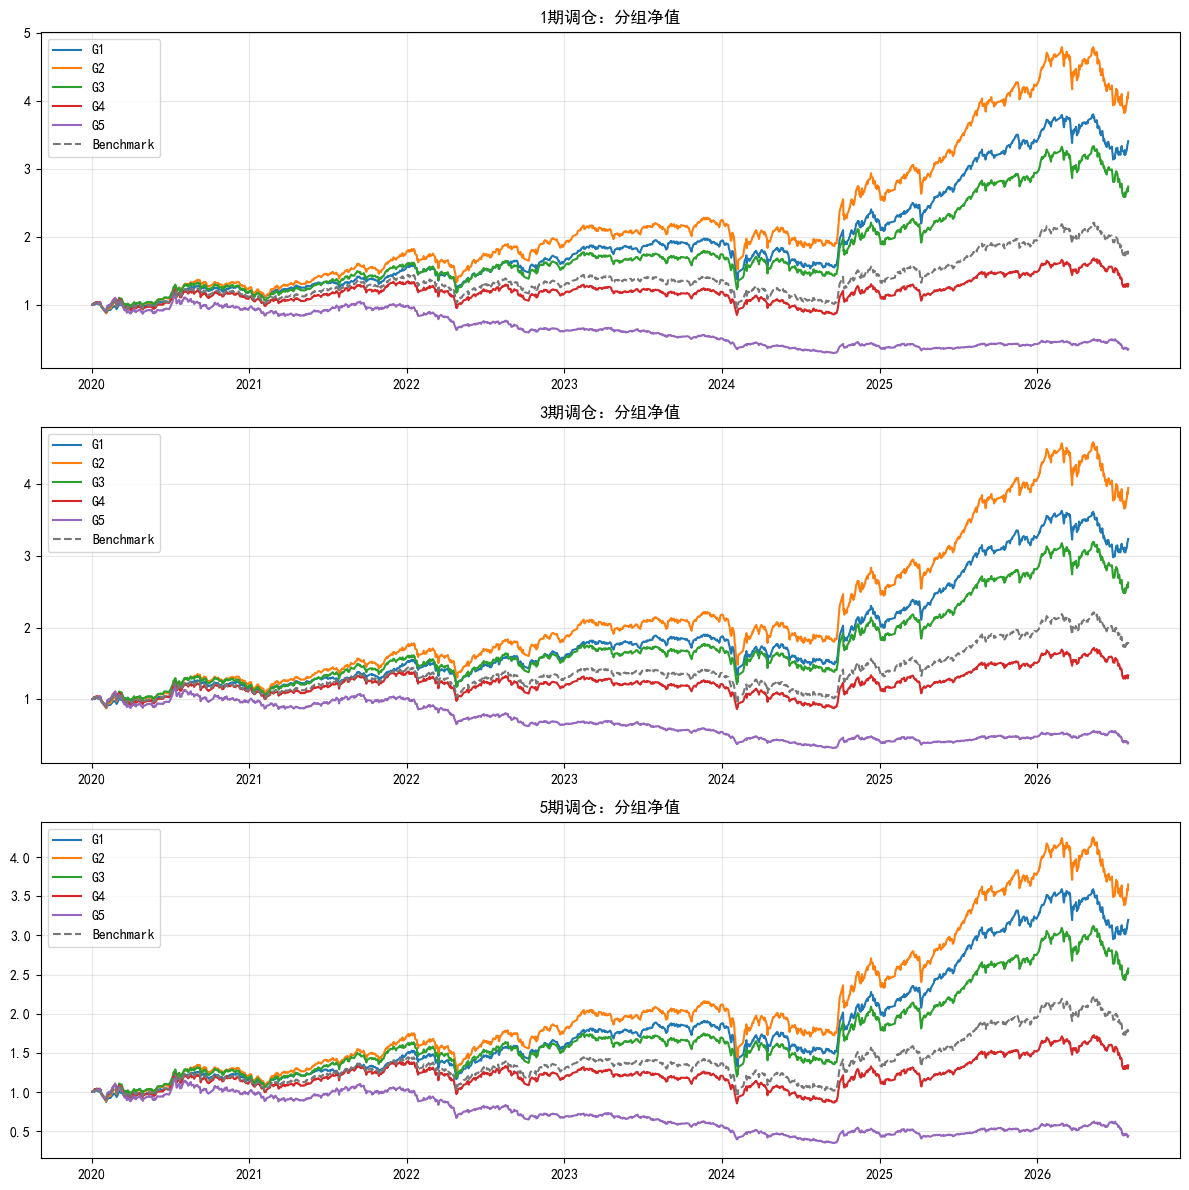

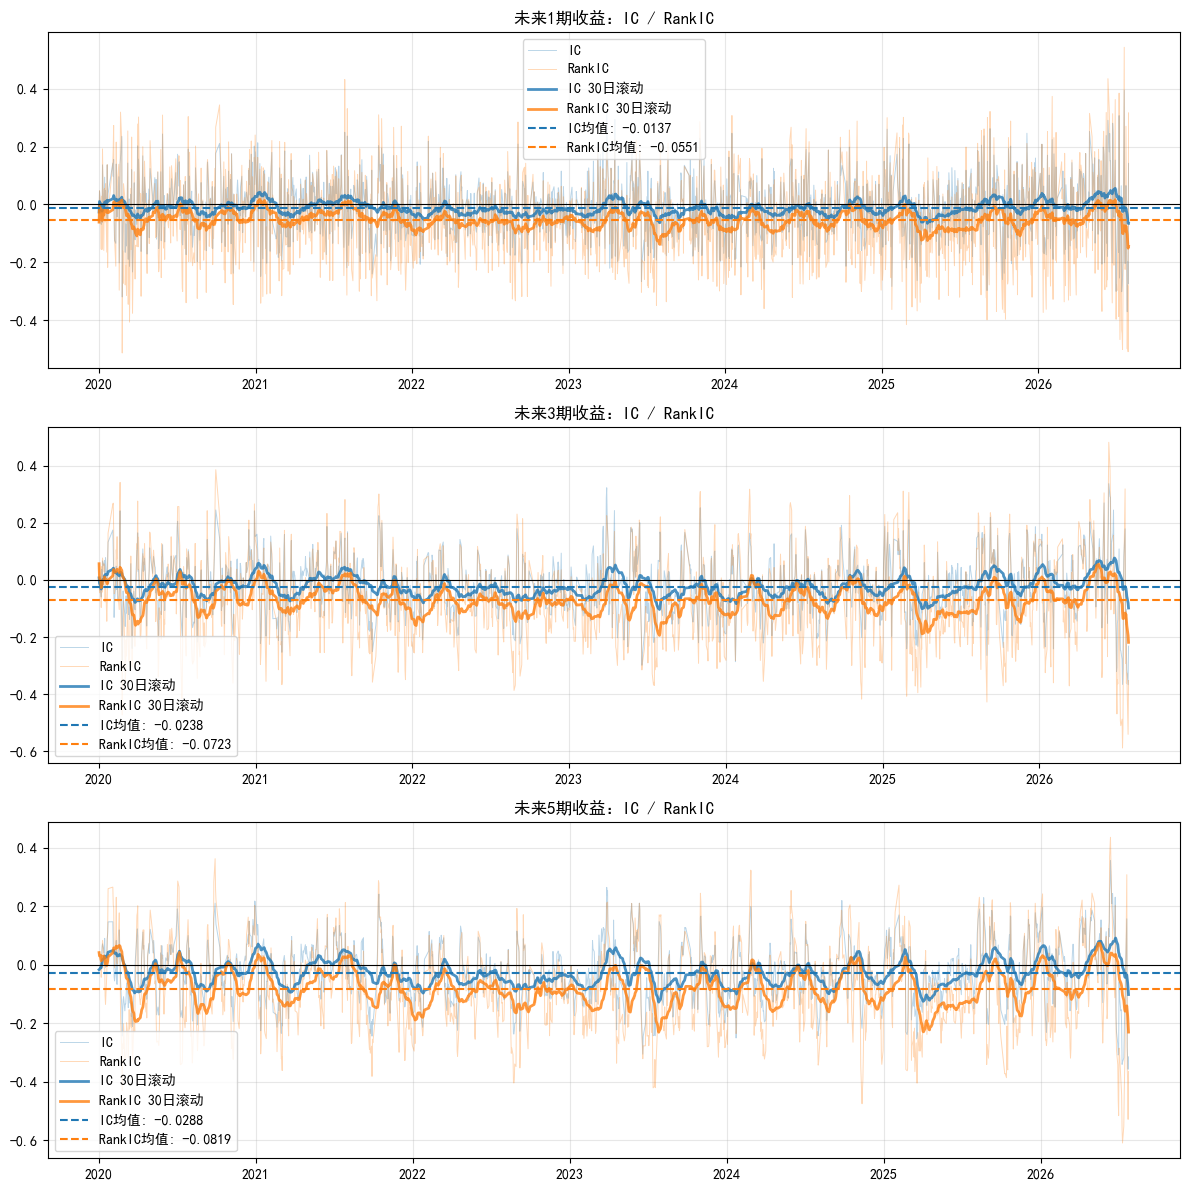

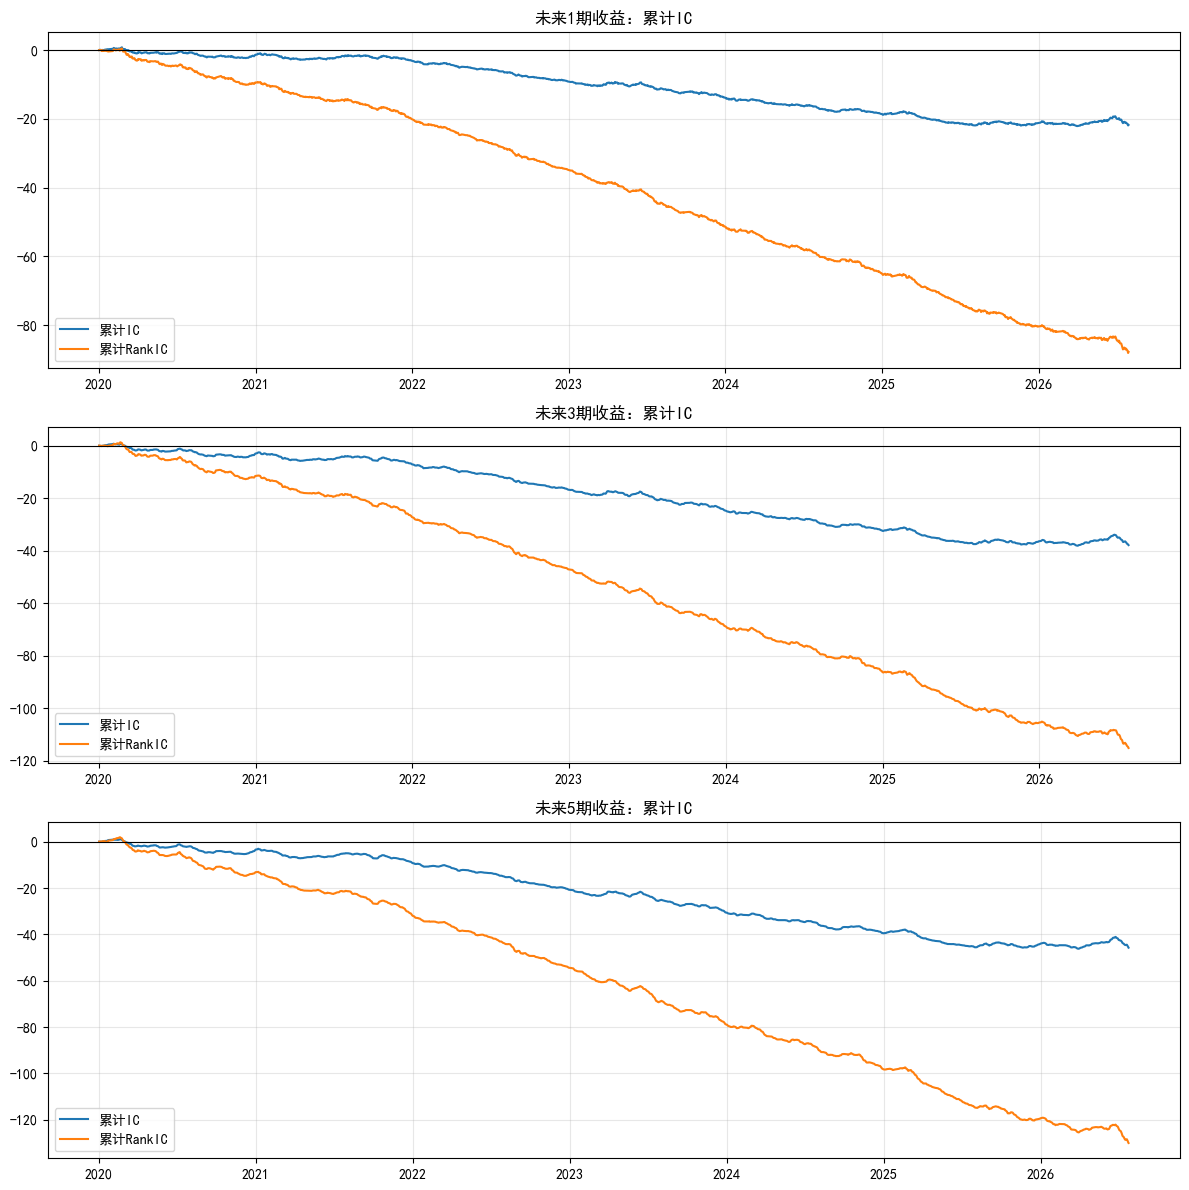

因子一阶截面秩自相关: 0.988556


window,ic_mean,ic_std,ic_positive_ratio,rank_ic_mean,rank_ic_std,rank_ic_positive_ratio,ic_ir,rank_ic_ir
i32,f64,f64,f64,f64,f64,f64,f64,f64
1,-0.013685,0.102267,0.440678,-0.055072,0.149008,0.349655,-0.133817,-0.369592
3,-0.02378,0.099255,0.39472,-0.072339,0.14417,0.293526,-0.239585,-0.50176
5,-0.028796,0.09859,0.375708,-0.081865,0.143461,0.273757,-0.292079,-0.570645


window,group,mean_return,annual_return,sharpe,max_drawdown,positive_ratio
i32,str,f64,f64,f64,f64,f64
1,"""G1""",0.000862,0.214314,1.016989,-0.306392,0.563089
1,"""G2""",0.001004,0.251413,1.062327,-0.334818,0.570621
1,"""G3""",0.000752,0.173138,0.779101,-0.31502,0.547395
1,"""G4""",0.000296,0.043688,0.296657,-0.367955,0.535468
1,"""G5""",-0.000501,-0.152914,-0.45005,-0.743101,0.516008
…,…,…,…,…,…,…
5,"""G1""",0.00082,0.201893,0.972297,-0.303325,0.558694
5,"""G2""",0.000926,0.227283,0.983385,-0.331969,0.569366
5,"""G3""",0.000712,0.161544,0.738888,-0.315025,0.54865


In [5]:
result = analyze_factor(
    data=analysis_data.select(
        "trading_date",
        "code",
        neutralized_factor_col,
        "daily_ret",
        "benchmark_ret",
    ),
    factor_col=neutralized_factor_col,
    ret_col="daily_ret",
    ret_windows=ret_windows,
    ic_windows=ic_windows,
    group_num=group_num,
    plot=True,
    save_result=False,
)

print(f"因子一阶截面秩自相关: {result['factor_autocorr']:.6f}")
display(result["ic_stats"])
display(result["group_stats"])

In [6]:
# 单独按日构造高因子组减低因子组收益，避免直接相减两组 CAGR。
low_group = "G1"
high_group = f"G{group_num}"
spread_returns = (
    result["group_returns"]
    .filter(pl.col("group").is_in([low_group, high_group]))
    .select("trading_date", "window", "group", "return")
    .pivot(on="group", index=["trading_date", "window"], values="return")
    .drop_nulls([low_group, high_group])
    .with_columns(
        (pl.col(high_group) - pl.col(low_group)).alias("spread_return")
    )
    .sort(["window", "trading_date"])
    .with_columns(
        (1 + pl.col("spread_return"))
        .cum_prod()
        .over("window")
        .alias("spread_nav")
    )
    .with_columns(
        (
            pl.col("spread_nav")
            / pl.max_horizontal(
                pl.lit(1.0),
                pl.col("spread_nav").cum_max().over("window"),
            )
            - 1
        ).alias("spread_drawdown")
    )
)

spread_summary = (
    spread_returns.group_by("window")
    .agg(
        pl.len().alias("days"),
        pl.col("spread_return").mean().alias("mean_daily_spread"),
        (pl.col("spread_nav").last().pow(252.0 / pl.len()) - 1).alias(
            "annualized_spread_return"
        ),
        (
            pl.col("spread_return").mean()
            / pl.col("spread_return").std()
            * np.sqrt(252)
        ).alias("spread_sharpe"),
        pl.col("spread_drawdown").min().alias("spread_max_drawdown"),
        pl.col("spread_nav").last().alias("spread_final_nav"),
    )
    .sort("window")
)

display(spread_summary)

window,days,mean_daily_spread,annualized_spread_return,spread_sharpe,spread_max_drawdown,spread_final_nav
i32,u32,f64,f64,f64,f64,f64
1,1593,-0.001363,-0.301468,-1.989026,-0.911701,0.103523
3,1593,-0.001253,-0.281605,-1.837081,-0.895878,0.123597
5,1593,-0.001175,-0.267362,-1.723892,-0.881647,0.139929


In [7]:
# 执行期验收：关键口径异常时让 Notebook 明确失败。
return_scale_error = return_scale_check.item()
assert return_scale_error < 1e-12, (
    f"daily_ret 与 pct/100 不一致: {return_scale_error}"
)
assert window_integrity_check["premature_non_nulls"].item() == 0
assert window_integrity_check["unexpected_nulls_after_full_window"].item() == 0
assert analysis_data["trading_date"].min() >= analysis_start_date
assert analysis_data["trading_date"].max() <= analysis_end_date
assert (
    analysis_data.select(pl.col(neutralized_factor_col).is_null().sum()).item()
    == 0
)
assert set(result["ic_stats"]["window"].to_list()) == set(ic_windows)
assert result["group_stats"].height == len(ret_windows) * group_num
assert spread_summary.height == len(ret_windows)
print("关键口径与结果结构检查通过。")

关键口径与结果结构检查通过。


## Takeaways

- G1 是市值中性化后的低成交额波动组，G5 是高成交额波动组。未来 1/3/5 日 RankIC 均为负（-0.0551、-0.0723、-0.0819），G5-G1 年化收益也均为负（-30.15%、-28.16%、-26.74%）；样本结果支持“成交额波动率越高，后续收益越弱”的负向因子方向。
- 分组关系大体呈下降趋势，但不是严格单调：1 日调仓口径下 G2 年化收益 25.14%，高于 G1 的 21.43%；G5 为 -15.29%。因此实际组合构建可优先研究规避最高波动组，而不应仅凭本次结果假设全截面线性单调。
- 因子一阶截面秩自相关为 0.9886，说明排序非常稳定。原始因子与总市值的每日绝对相关系数均值为 0.4357，市值中性化后最大绝对相关降至 1.78e-15；若不做中性化，结果会明显混入规模暴露。
- 数据和窗口检查通过：完整窗口前没有提前产生因子，`daily_ret` 与 `pct/100` 最大误差为 8.88e-16。最终样本包含 0.3053% 的零成交额/停牌记录；本 Notebook 为忠实实现 `STD(amount, 20)` 而保留这些零值，后续可单独做剔除停牌日或延续窗口的稳健性检验。
- 因子在 t 日收盘后才能获得完整成交额，而当前理论框架将 t→t+1 的收盘到收盘收益计入组合，相当于假设能在 t 日收盘成交。形成可交易策略前，应改用下一交易日开盘成交或将信号再延迟一期，并加入可交易股票池、涨跌停/停牌约束、换手率、手续费和滑点。
- 当前仅做线性 `total_mv` 中性化，尚未进行行业中性化或对数市值中性化；这些是下一步稳健性检验，而不是本次严格 `STD(amount, 20)` 定义的一部分。